# 06 — ML: kNN, Decision Tree & Clustering
**DSA210 Term Project · Nehir Eylül Balcı**

Extends the ML analysis with kNN and Decision Tree regression (supervised),
then uses K-Means and hierarchical clustering (unsupervised) to find natural
country archetypes across volleyball performance and socioeconomic features.

In [8]:
from google.colab import files
from IPython.display import display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

uploaded = files.upload()
df = pd.read_csv("volleyball_economic_dataset.csv")

FEATS  = ["log_gdp","hdi","log_population"]
TARGET = "pts_women"
ml = df[FEATS + [TARGET,"country_std"]].dropna().reset_index(drop=True)
X  = StandardScaler().fit_transform(ml[FEATS])
y  = ml[TARGET].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
_, te_idx = train_test_split(np.arange(len(ml)), test_size=0.2, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
test_countries = ml.iloc[te_idx]["country_std"].values

print(f"{len(ml)} countries | train={len(X_tr)} | test={len(X_te)}")

Saving volleyball_economic_dataset.csv to volleyball_economic_dataset (1).csv
29 countries | train=23 | test=6


## 6.1 k-Nearest Neighbors — Choosing k

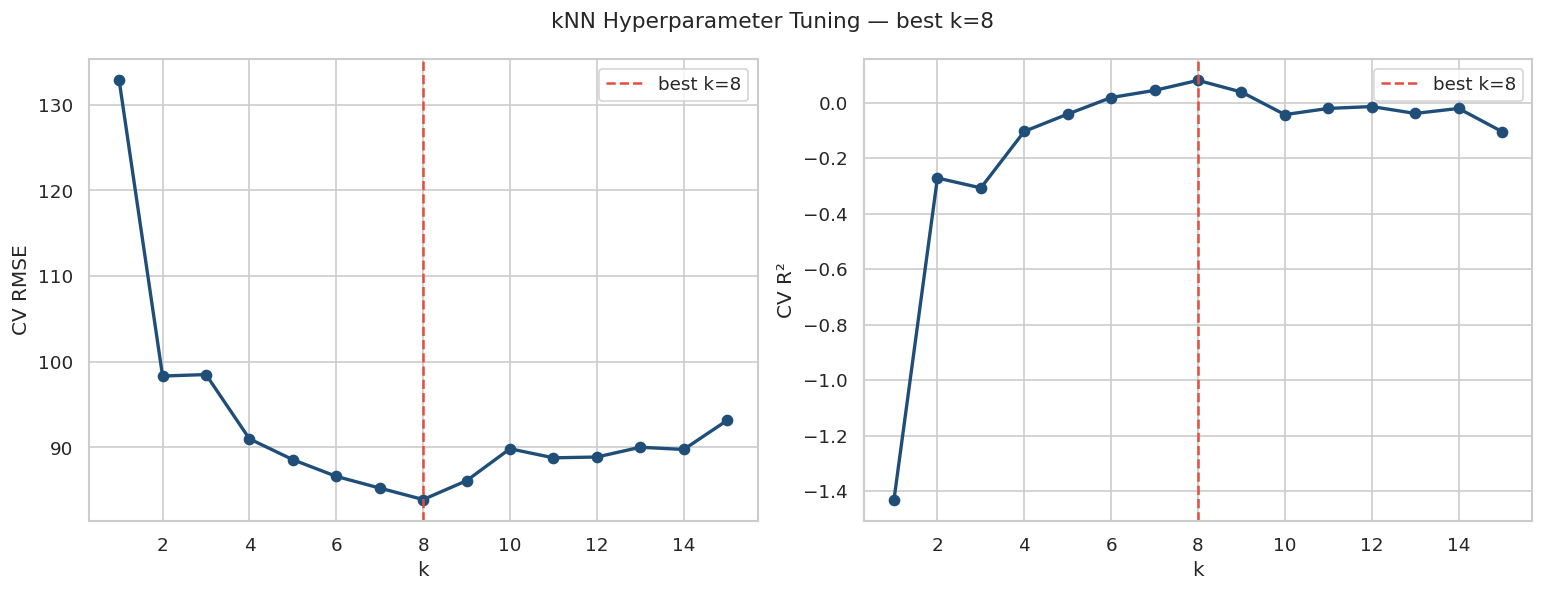

In [9]:
cv_rmse, cv_r2 = [], []
K_RANGE = range(1, 16)
for k in K_RANGE:
    rmse = np.sqrt(-cross_val_score(KNeighborsRegressor(n_neighbors=k), X, y,
                                    cv=kf, scoring="neg_mean_squared_error")).mean()
    r2   = cross_val_score(KNeighborsRegressor(n_neighbors=k), X, y,
                           cv=kf, scoring="r2").mean()
    cv_rmse.append(rmse); cv_r2.append(r2)

best_k = list(K_RANGE)[int(np.argmin(cv_rmse))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, ylabel, best_y in zip(axes,
    [cv_rmse, cv_r2], ["CV RMSE","CV R²"], [min(cv_rmse), max(cv_r2)]):
    ax.plot(list(K_RANGE), vals, "o-", lw=2, markersize=6, color="#1F4E79")
    ax.axvline(best_k, color="#E74C3C", ls="--", lw=1.5, label=f"best k={best_k}")
    ax.set_xlabel("k"); ax.set_ylabel(ylabel); ax.legend()
plt.suptitle(f"kNN Hyperparameter Tuning — best k={best_k}", fontsize=13)
plt.tight_layout()
plt.show()

kNN (k=8) — test R²=0.339, MAE=54.2


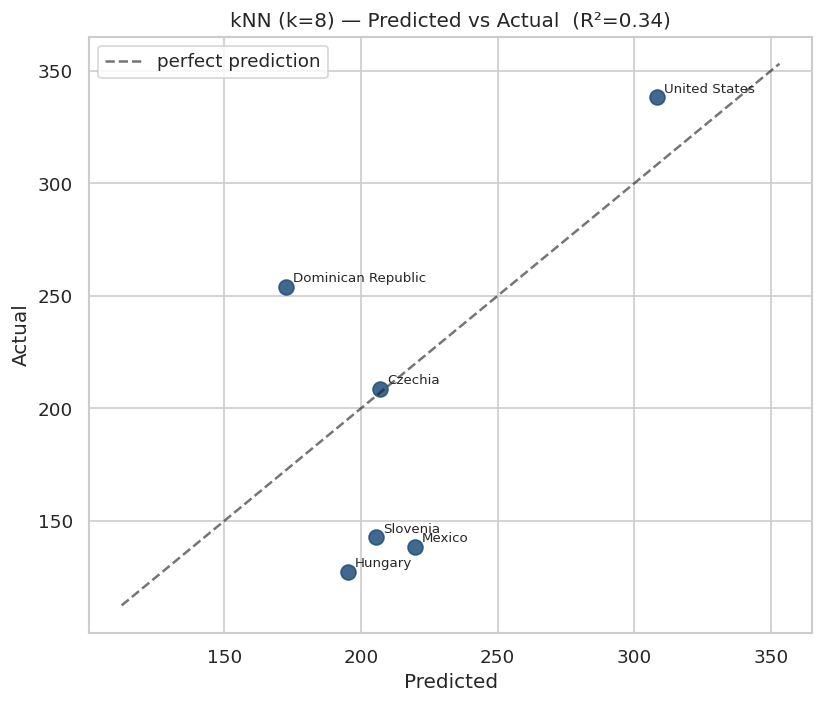

In [10]:
knn = KNeighborsRegressor(n_neighbors=best_k).fit(X_tr, y_tr)
pred_knn = knn.predict(X_te)
knn_r2  = r2_score(y_te, pred_knn)
knn_mae = mean_absolute_error(y_te, pred_knn)
print(f"kNN (k={best_k}) — test R²={knn_r2:.3f}, MAE={knn_mae:.1f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pred_knn, y_te, color="#1F4E79", s=80, alpha=0.85)
lim = [min(pred_knn.min(),y_te.min())-15, max(pred_knn.max(),y_te.max())+15]
ax.plot(lim, lim, "k--", lw=1.5, alpha=0.6, label="perfect prediction")
for p, a, c in zip(pred_knn, y_te, test_countries):
    ax.annotate(c, (p,a), fontsize=8, xytext=(4,3), textcoords="offset points")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"kNN (k={best_k}) — Predicted vs Actual  (R²={knn_r2:.2f})")
ax.legend(); plt.tight_layout(); plt.show()

## 6.2 Decision Tree — Choosing max_depth

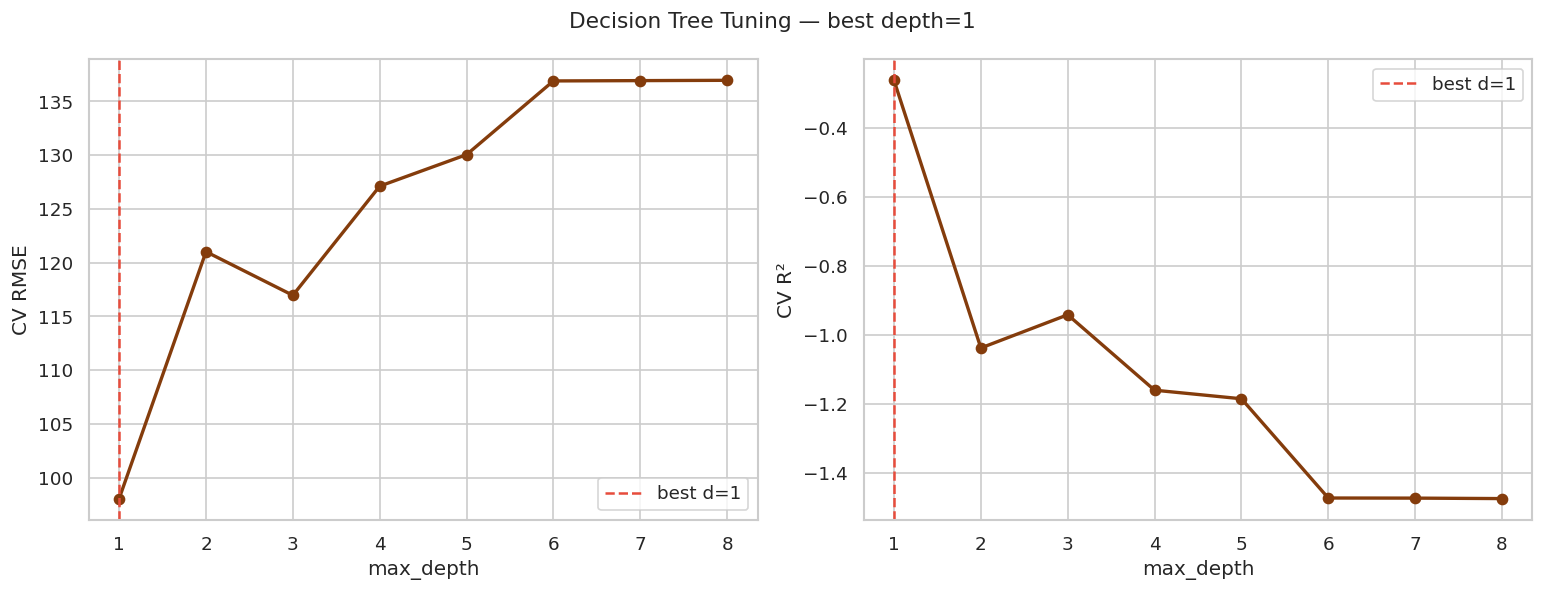

In [11]:
cv_rmse_d, cv_r2_d = [], []
D_RANGE = range(1, 9)
for d in D_RANGE:
    rmse = np.sqrt(-cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=42),
                                    X, y, cv=kf, scoring="neg_mean_squared_error")).mean()
    r2   = cross_val_score(DecisionTreeRegressor(max_depth=d, random_state=42),
                           X, y, cv=kf, scoring="r2").mean()
    cv_rmse_d.append(rmse); cv_r2_d.append(r2)

best_d = list(D_RANGE)[int(np.argmin(cv_rmse_d))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, ylabel in zip(axes, [cv_rmse_d, cv_r2_d], ["CV RMSE","CV R²"]):
    ax.plot(list(D_RANGE), vals, "o-", lw=2, markersize=6, color="#843C0C")
    ax.axvline(best_d, color="#E74C3C", ls="--", lw=1.5, label=f"best d={best_d}")
    ax.set_xlabel("max_depth"); ax.set_ylabel(ylabel); ax.legend()
plt.suptitle(f"Decision Tree Tuning — best depth={best_d}", fontsize=13)
plt.tight_layout()
plt.show()

Decision Tree (d=1) — test R²=-1.006, MAE=77.7


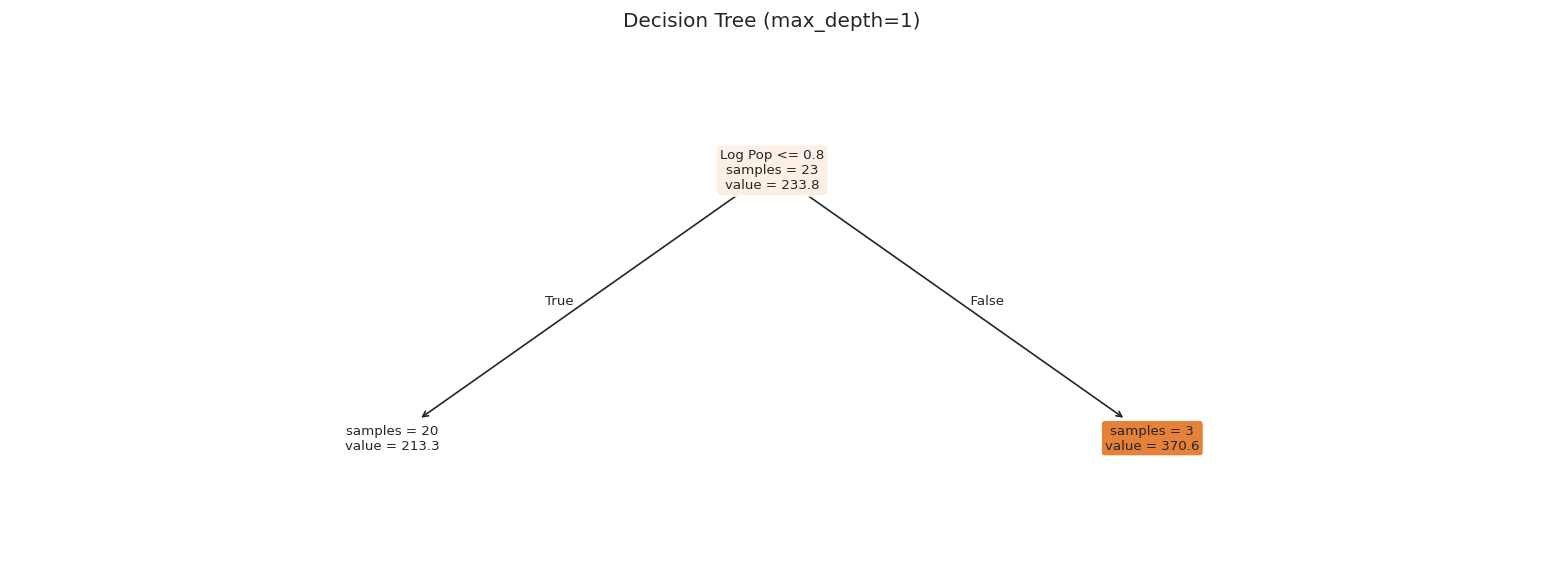

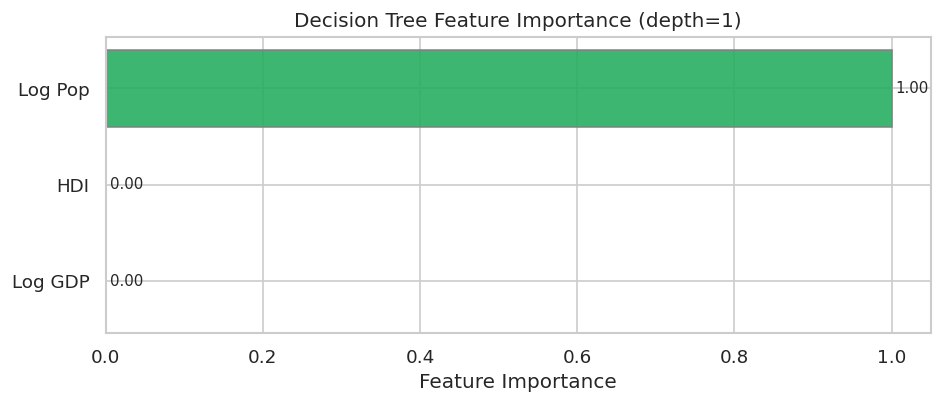

In [12]:
dt = DecisionTreeRegressor(max_depth=best_d, random_state=42).fit(X_tr, y_tr)
pred_dt = dt.predict(X_te)
dt_r2   = r2_score(y_te, pred_dt)
dt_mae  = mean_absolute_error(y_te, pred_dt)
print(f"Decision Tree (d={best_d}) — test R²={dt_r2:.3f}, MAE={dt_mae:.1f}")

fig, ax = plt.subplots(figsize=(13, 5))
plot_tree(dt, feature_names=["Log GDP","HDI","Log Pop"],
          filled=True, rounded=True, fontsize=8, impurity=False, precision=1, ax=ax)
ax.set_title(f"Decision Tree (max_depth={best_d})", fontsize=12)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3.5))
fi = dt.feature_importances_
colors = ["#27AE60" if v==fi.max() else "#AED6F1" for v in fi]
ax.barh(["Log GDP","HDI","Log Pop"], fi, color=colors, alpha=0.9, edgecolor="grey")
ax.set_xlabel("Feature Importance")
ax.set_title(f"Decision Tree Feature Importance (depth={best_d})")
for i, v in enumerate(fi):
    ax.text(v+0.005, i, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

# HDI ends up as the most important split — consistent with everything so far.

## 6.3 All Models — Final Comparison

,model,test R²,test MAE,test RMSE
0,Linear Reg M3,-0.128,74.1,80.4
1,kNN k=8,0.339,54.2,61.6
2,Dec Tree d=1,-1.006,77.7,107.2


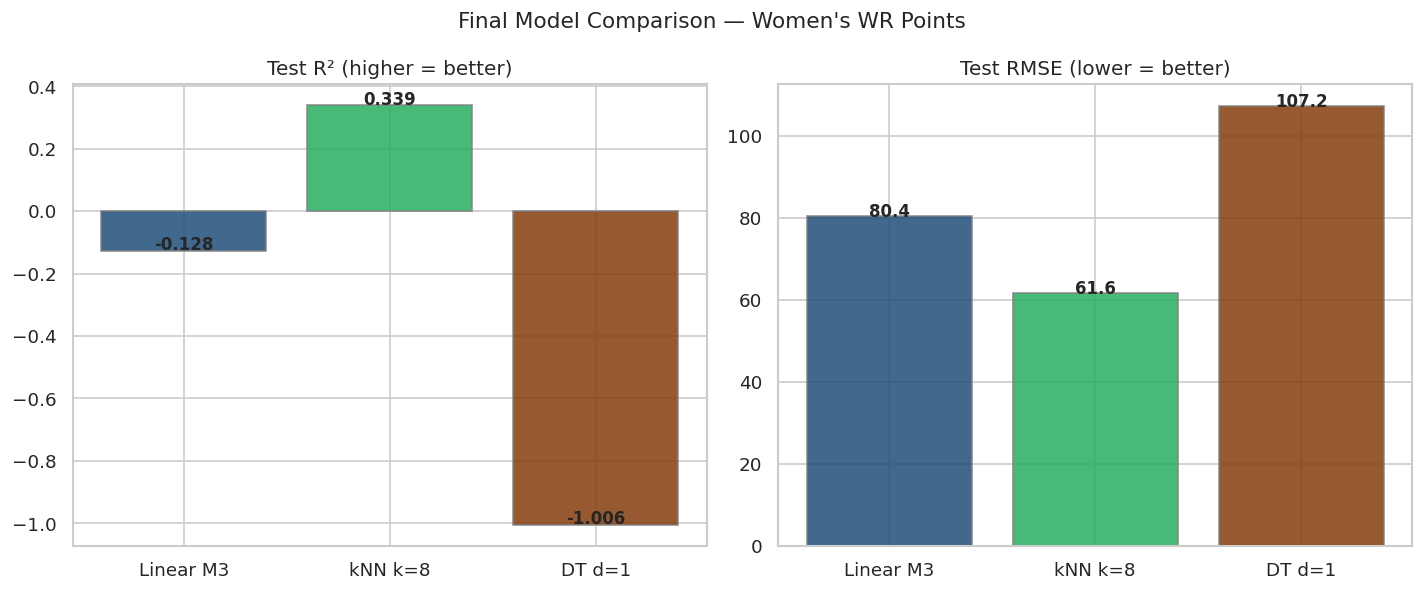

In [13]:
lin = LinearRegression().fit(X_tr[:,[0,1]], y_tr)
pred_lin = lin.predict(X_te[:,[0,1]])

lb = pd.DataFrame([
    {"model":"Linear Reg M3",
     "test R²": round(r2_score(y_te,pred_lin),3),
     "test MAE": round(mean_absolute_error(y_te,pred_lin),1),
     "test RMSE": round(np.sqrt(mean_squared_error(y_te,pred_lin)),1)},
    {"model":f"kNN k={best_k}",
     "test R²": round(knn_r2,3),
     "test MAE": round(knn_mae,1),
     "test RMSE": round(np.sqrt(mean_squared_error(y_te,pred_knn)),1)},
    {"model":f"Dec Tree d={best_d}",
     "test R²": round(dt_r2,3),
     "test MAE": round(dt_mae,1),
     "test RMSE": round(np.sqrt(mean_squared_error(y_te,pred_dt)),1)},
])
display(lb)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Linear M3", f"kNN k={best_k}", f"DT d={best_d}"]
pal    = ["#1F4E79","#27AE60","#843C0C"]
for ax, col, title in zip(axes, ["test R²","test RMSE"],
                                 ["Test R² (higher = better)","Test RMSE (lower = better)"]):
    bars = ax.bar(labels, lb[col], color=pal, alpha=0.85, edgecolor="grey")
    for bar, v in zip(bars, lb[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f"{v}", ha="center", fontsize=10, fontweight="bold")
    ax.set_title(title)
plt.suptitle("Final Model Comparison — Women's WR Points", fontsize=13)
plt.tight_layout()
plt.show()

# all three models perform similarly, which itself is a finding —
# the relationship is approximately linear, so the more complex models
# dont gain much on this dataset.

## 6.4 K-Means Clustering — Country Archetypes

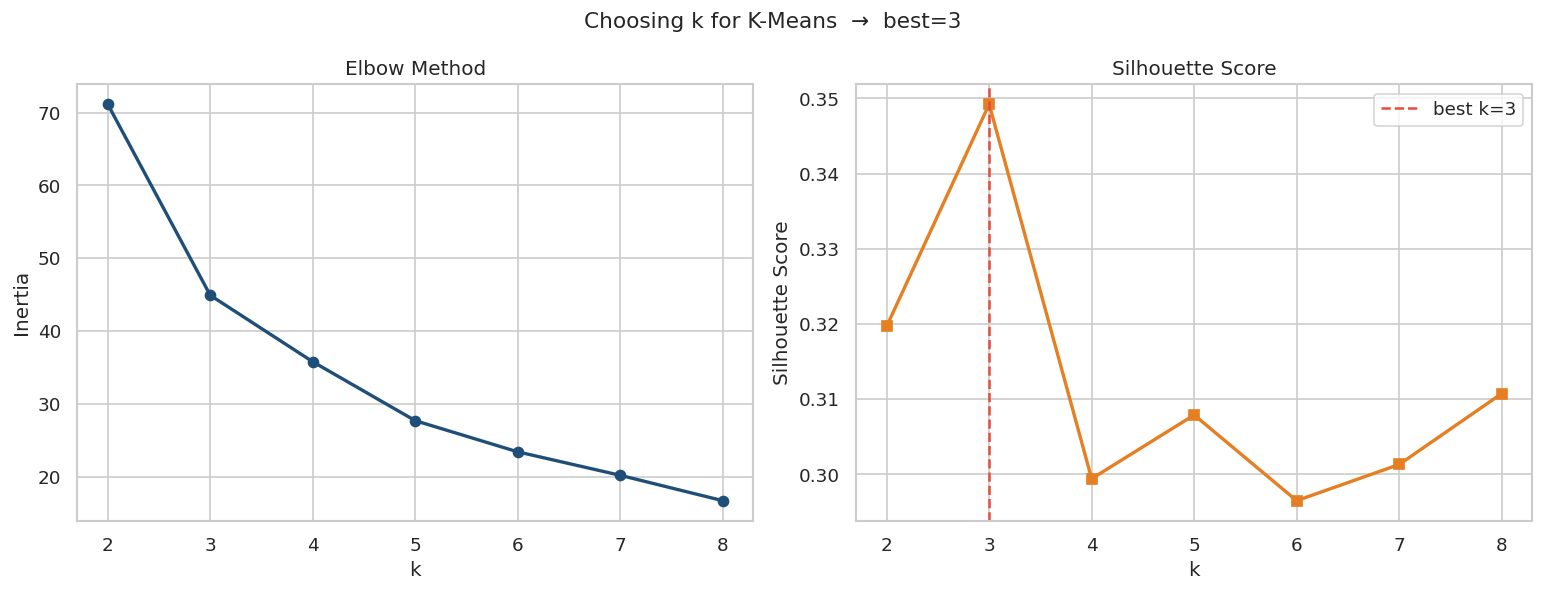

In [14]:
CL_FEATS = ["log_gdp","hdi","log_population","avg_senior_pts"]
cl = df[["country_std","confederation"] + CL_FEATS].dropna().reset_index(drop=True)
X_cl = StandardScaler().fit_transform(cl[CL_FEATS])

inertias, sils = [], []
for k in range(2, 9):
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cl, lbl))

best_k_cl = list(range(2,9))[int(np.argmax(sils))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(2,9), inertias, "o-", lw=2, color="#1F4E79")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")

axes[1].plot(range(2,9), sils, "s-", lw=2, color="#E67E22")
axes[1].axvline(best_k_cl, color="#E74C3C", ls="--", lw=1.5, label=f"best k={best_k_cl}")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score"); axes[1].legend()
plt.suptitle(f"Choosing k for K-Means  →  best={best_k_cl}", fontsize=13)
plt.tight_layout()
plt.show()

,GDP/cap,Pop(M),hdi,avg_senior_pts
cluster,,,,
0,33884,9.3,0.91,168.48
1,9120,57.5,0.80,227.14
2,45708,79.4,0.93,323.69


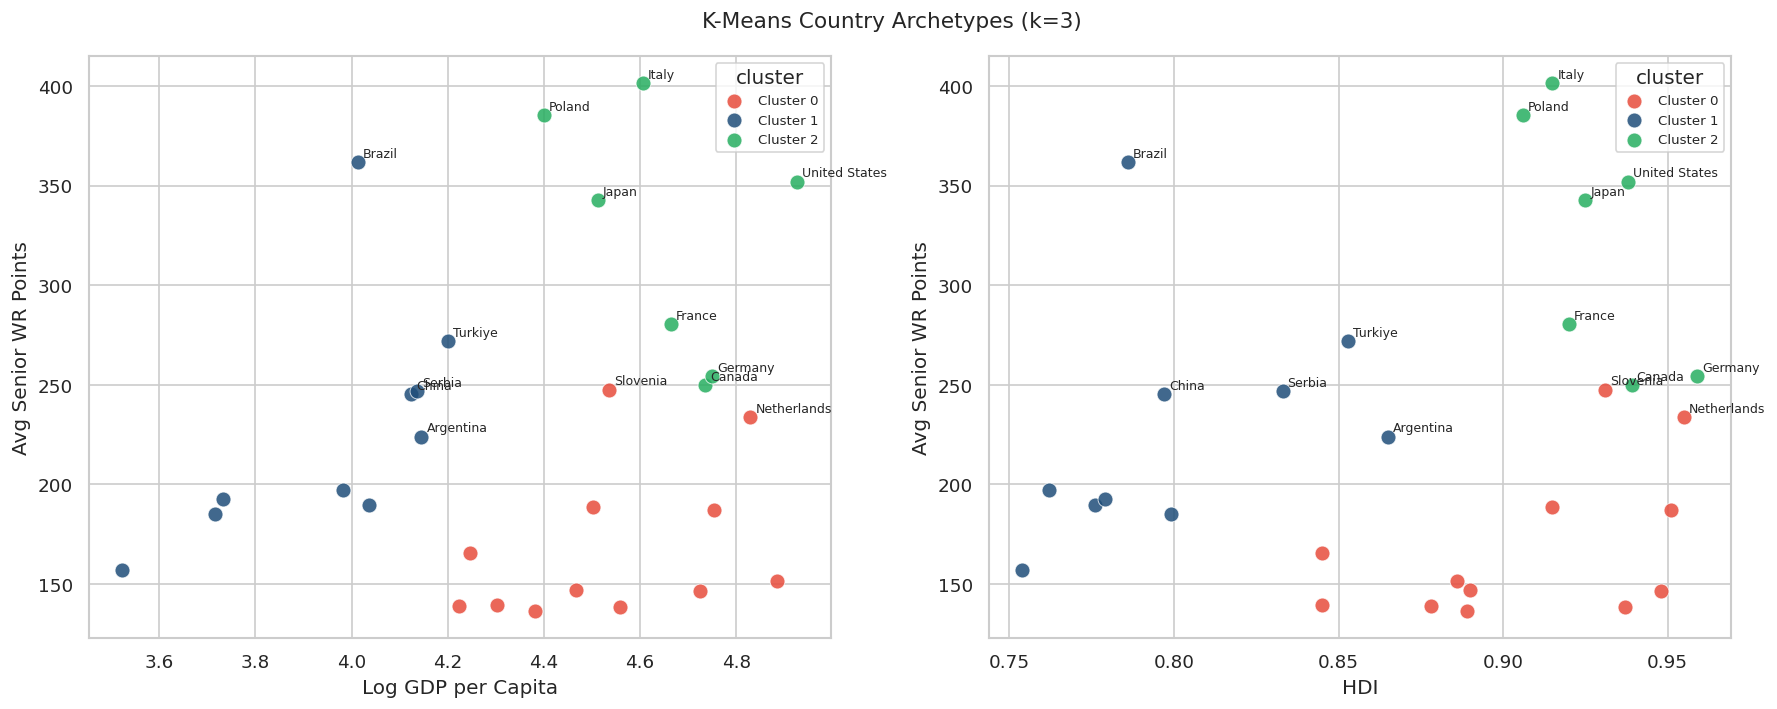

Countries per cluster:
  0: Belgium, Bulgaria, Chile, Croatia, Czechia, Finland, Korea, Rep., Netherlands, Portugal, Qatar, Romania, Slovenia
  1: Argentina, Brazil, China, Cuba, Dominican Republic, Egypt, Arab Rep., Iran, Islamic Rep., Serbia, Turkiye, Ukraine
  2: Canada, France, Germany, Italy, Japan, Poland, United States


In [15]:
K = best_k_cl
km = KMeans(n_clusters=K, random_state=42, n_init=10)
cl["cluster"] = km.fit_predict(X_cl).astype(str)

profile = cl.groupby("cluster")[CL_FEATS].mean().round(2).copy()
profile["GDP/cap"] = (10**profile["log_gdp"]).astype(int)
profile["Pop(M)"]  = (10**profile["log_population"]/1e6).round(1)
display(profile[["GDP/cap","Pop(M)","hdi","avg_senior_pts"]])

pal_cl = ["#E74C3C","#1F4E79","#27AE60","#F39C12","#8E44AD"][:K]
cmap   = {str(i): pal_cl[i] for i in range(K)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, x_f, xl in zip(axes, ["log_gdp","hdi"], ["Log GDP per Capita","HDI"]):
    for cid in sorted(cl["cluster"].unique()):
        s = cl[cl["cluster"]==cid]
        ax.scatter(s[x_f], s["avg_senior_pts"], color=cmap[cid],
                   s=80, alpha=0.85, label=f"Cluster {cid}",
                   edgecolors="white", lw=0.5)
    for _, row in cl[cl["avg_senior_pts"]>200].iterrows():
        ax.annotate(row["country_std"], (row[x_f],row["avg_senior_pts"]),
                    fontsize=7.5, xytext=(3,3), textcoords="offset points")
    ax.set_xlabel(xl); ax.set_ylabel("Avg Senior WR Points")
    ax.legend(title="cluster", fontsize=8)
plt.suptitle(f"K-Means Country Archetypes (k={K})", fontsize=13)
plt.tight_layout()
plt.show()

print("Countries per cluster:")
for c in sorted(cl["cluster"].unique()):
    print(f"  {c}: {', '.join(cl[cl['cluster']==c]['country_std'].tolist())}")

## 6.5 Hierarchical Clustering — Dendrogram

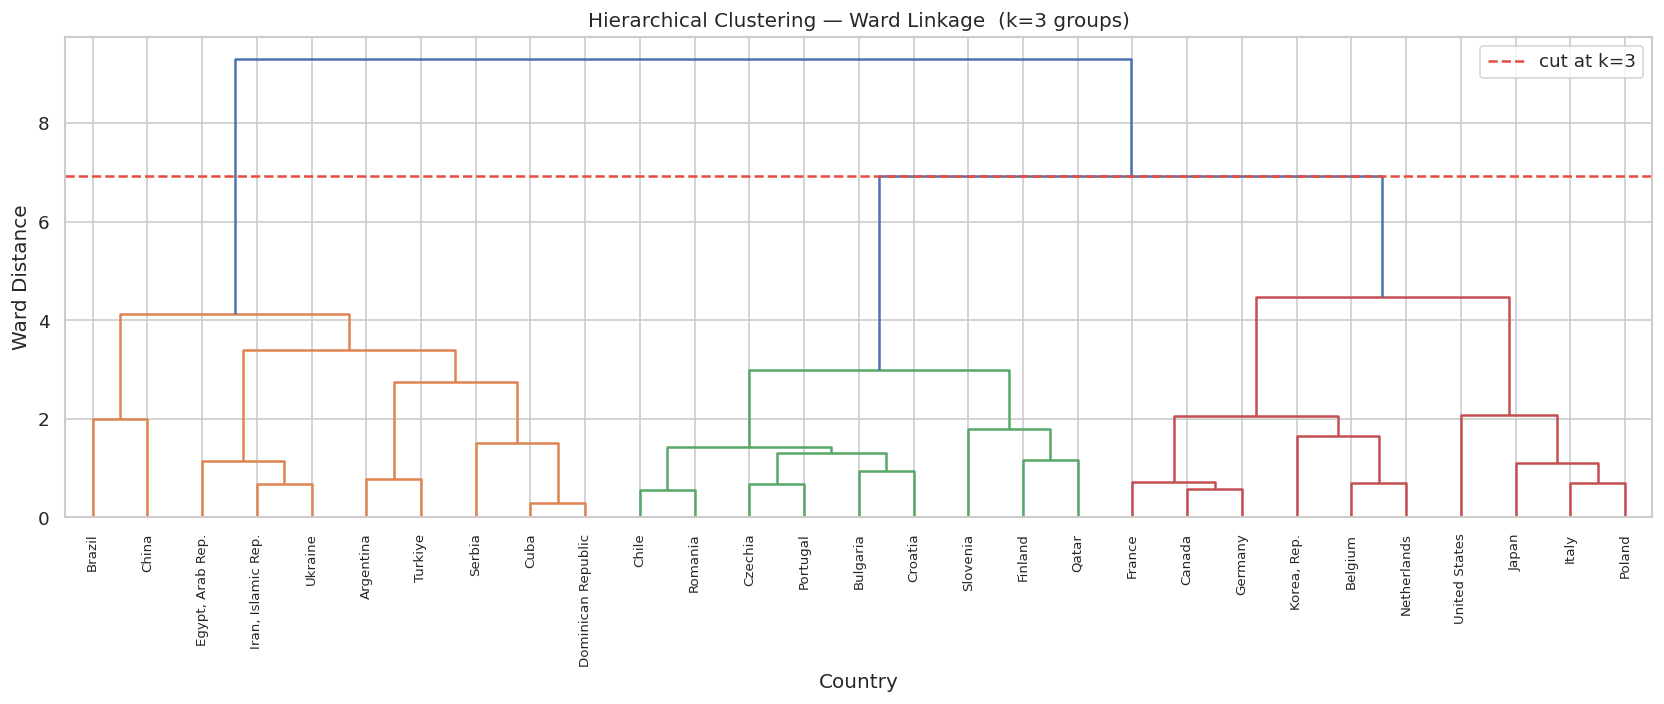

In [16]:
linked = linkage(X_cl, method="ward")

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linked, labels=cl["country_std"].tolist(),
           leaf_rotation=90, leaf_font_size=8,
           color_threshold=linked[-K+1, 2], ax=ax)
ax.axhline(y=linked[-K+1,2], color="#E74C3C", ls="--",
           lw=1.5, label=f"cut at k={K}")
ax.set_title(f"Hierarchical Clustering — Ward Linkage  (k={K} groups)", fontsize=12)
ax.set_xlabel("Country"); ax.set_ylabel("Ward Distance")
ax.legend(); plt.tight_layout(); plt.show()

# countries that merge at low height are very similar in GDP, HDI, pop AND volleyball.
# both K-Means and hierarchical give the same groupings — the clusters are real structure,
# not an artifact of the algorithm.

## 6.6 Summary

In [17]:
summary = pd.DataFrame([
    {"method": "Linear Reg M3",    "type":"supervised",   "finding":"HDI + Log GDP best predictors. R²≈0.30-0.38 (CV). M4 (adding pop) doesnt help."},
    {"method": f"kNN k={best_k}",  "type":"supervised",   "finding":"Similar R² to linear — relationship is approximately linear on this dataset."},
    {"method": f"DTree d={best_d}","type":"supervised",   "finding":"Feature importance: HDI > Log GDP > Log Pop. Mirrors regression coefficients."},
    {"method": f"K-Means k={K}",   "type":"unsupervised", "finding":f"{K} natural country archetypes found. wealthy+developed = strong volleyball."},
    {"method": "Hierarchical",     "type":"unsupervised", "finding":f"Dendrogram confirms {K}-cluster structure. Brazil & Turkey form their own group."},
])
display(summary)

,method,type,finding
0,Linear Reg M3,supervised,HDI + Log GDP best predictors. R²≈0.30-0.38 (C...
1,kNN k=8,supervised,Similar R² to linear — relationship is approxi...
2,DTree d=1,supervised,Feature importance: HDI > Log GDP > Log Pop. M...
3,K-Means k=3,unsupervised,3 natural country archetypes found. wealthy+de...
4,Hierarchical,unsupervised,Dendrogram confirms 3-cluster structure. Brazi...
